# Mini-Project 02: Model Comparison Dashboard

A comprehensive benchmark comparing OLS, Ridge, Lasso, ElasticNet, Huber, and RANSAC on California Housing with a visual performance benchmark chart.

          Model  Test R2  Test RMSE
      OLS (SVD) 0.660514   0.703338
 Newton-Raphson 0.660514   0.703338
     Ridge (L2) 0.378336   0.951769
     Lasso (L1) 0.657700   0.706247
     ElasticNet 0.656992   0.706977
Huber Regressor 0.174504   1.096758


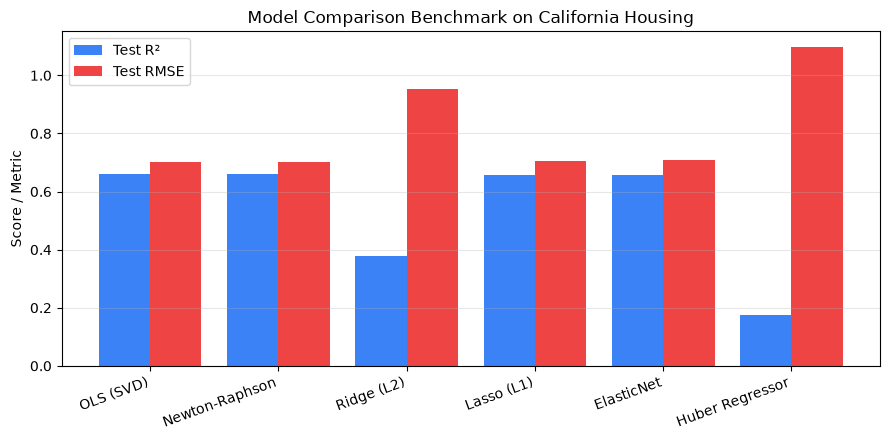

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Robust import setup: traverse up until 'src' directory is found
root_dir = Path.cwd().resolve()
while not (root_dir / "src").exists() and root_dir != root_dir.parent:
    root_dir = root_dir.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.solvers import ClosedFormLinearRegression, NewtonLinearRegression
from src.linear_regression import GradientDescentLinearRegression, compute_mse, compute_r2
from src.robust import HuberRegressorScratch, RANSACRegressorScratch
from src.pipeline import StandardScalerScratch

df = pd.read_csv(root_dir / "data" / "california_housing" / "california_housing.csv")
features = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude"]
X = df[features].values
y = df["MedHouseVal"].values

# Standardize
scaler = StandardScalerScratch()
X_scaled = scaler.fit_transform(X)

# 80/20 split
split = int(0.8 * len(X))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y[:split], y[split:]

suite = {
    "OLS (SVD)": ClosedFormLinearRegression(method="svd"),
    "Newton-Raphson": NewtonLinearRegression(),
    "Ridge (L2)": GradientDescentLinearRegression(penalty="l2", alpha=1.0, lr=0.02, n_iters=300, optimizer="adam"),
    "Lasso (L1)": GradientDescentLinearRegression(penalty="l1", alpha=0.01, lr=0.02, n_iters=300, optimizer="adam"),
    "ElasticNet": GradientDescentLinearRegression(penalty="elasticnet", alpha=0.01, l1_ratio=0.5, lr=0.02, n_iters=300, optimizer="adam"),
    "Huber Regressor": HuberRegressorScratch(epsilon=1.35, lr=0.02, max_iter=300)
}

dashboard = []
for name, model in suite.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    dashboard.append({
        "Model": name,
        "Test R2": compute_r2(y_test, y_pred),
        "Test RMSE": np.sqrt(compute_mse(y_test, y_pred))
    })

res_df = pd.DataFrame(dashboard)
print(res_df.to_string(index=False))

# Plot performance benchmark
plt.figure(figsize=(9, 4.5))
x_pos = np.arange(len(res_df))
plt.bar(x_pos - 0.2, res_df["Test R2"], width=0.4, label="Test R²", color="#3b82f6")
plt.bar(x_pos + 0.2, res_df["Test RMSE"], width=0.4, label="Test RMSE", color="#ef4444")
plt.xticks(x_pos, res_df["Model"], rotation=20, ha="right")
plt.title("Model Comparison Benchmark on California Housing")
plt.ylabel("Score / Metric")
plt.legend()
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()